In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)

print("Kutuphaneler yuklendi!")

Kutuphaneler yuklendi!


In [12]:
#parse_dates=['date'] ---> string olarak değil tarih olarak okumayı sağlar 
train        = pd.read_csv('../data/train.csv', parse_dates=['date'])
test         = pd.read_csv('../data/test.csv',  parse_dates=['date'])
stores       = pd.read_csv('../data/stores.csv')
oil          = pd.read_csv('../data/oil.csv',   parse_dates=['date'])
holidays     = pd.read_csv('../data/holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv('../data/transactions.csv',    parse_dates=['date'])

print("Veriler yuklendi!")
print(f"train dataseti şekli: {train.shape}") 

Veriler yuklendi!
train dataseti şekli: (3000888, 6)


In [ ]:
#Modeli eğiteceğimiz train data set, tanımak için ilk 10 satıra ön bakış 
print("----TRAIN DATA SET----")
print(f"Tarih aralıkları: {train['date'].min()} -- {train['date'].max()}")
print(f"Toplam Mağaza Sayısı: {train['store_nbr'].nunique}") # eşsiz birbirinden farklı mağazalar için toplamı -> .nunique
print(f"Urun Kategorisi: {train['family'].nunique}")
print(f"Toplam Satır: {len(train):,}")
train.head(10)

----TRAIN DATA SET----
Tarih aralıkları: 2013-01-01 00:00:00 -- 2017-08-15 00:00:00
Toplam Mağaza Sayısı: <bound method IndexOpsMixin.nunique of 0          1
1          1
2          1
3          1
4          1
          ..
3000883    9
3000884    9
3000885    9
3000886    9
3000887    9
Name: store_nbr, Length: 3000888, dtype: int64>
Urun Kategorisi: <bound method IndexOpsMixin.nunique of 0                          AUTOMOTIVE
1                           BABY CARE
2                              BEAUTY
3                           BEVERAGES
4                               BOOKS
                      ...            
3000883                       POULTRY
3000884                PREPARED FOODS
3000885                       PRODUCE
3000886    SCHOOL AND OFFICE SUPPLIES
3000887                       SEAFOOD
Name: family, Length: 3000888, dtype: str>
Toplam Satır sayısı: 3,000,888


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0
6,6,2013-01-01,1,CELEBRATION,0.0,0
7,7,2013-01-01,1,CLEANING,0.0,0
8,8,2013-01-01,1,DAIRY,0.0,0
9,9,2013-01-01,1,DELI,0.0,0


In [55]:
# Veri Kalitesi Kontrolü (eksik değer var mı nerede var?)
# Her dosyadaki eksik değerleri tablo halinde göster.
dosyalar = {
    'train'       : train,
    'test'        : test,
    'stores'      : stores,
    'oil'         : oil,
    'holidays'    : holidays,
    'transactions': transactions
}

for isim, df in dosyalar.items():
    eksik = df.isnull().sum()          # Her sütundaki eksik değer sayısı
    eksik = eksik[eksik > 0]           # Sadece eksik olanları filtrele
    if len(eksik) > 0:
        print(f"{isim}: eksik değer var!!")
    else:
        print(f"✅  {isim}: eksik değer yok")

print("Oil eksik çıktı acil reaksiyon almaya gerek yok çünkü borsanın kapalı olduğu günler vs. fakat sales veya stores eksik hatalı olsaydı direkt düzeltme gerekirdi!! ")

✅  train: eksik değer yok
✅  test: eksik değer yok
✅  stores: eksik değer yok
oil: eksik değer var!!
✅  holidays: eksik değer yok
✅  transactions: eksik değer yok
Oil eksik çıktı acil reaksiyon almaya gerek yok çünkü borsanın kapalı olduğu günler vs. fakat sales veya stores eksik hatalı olsaydı direkt düzeltme gerekirdi!! 


count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64
Sıfır Satış Olan Gün sayısı Oranı: %31.3


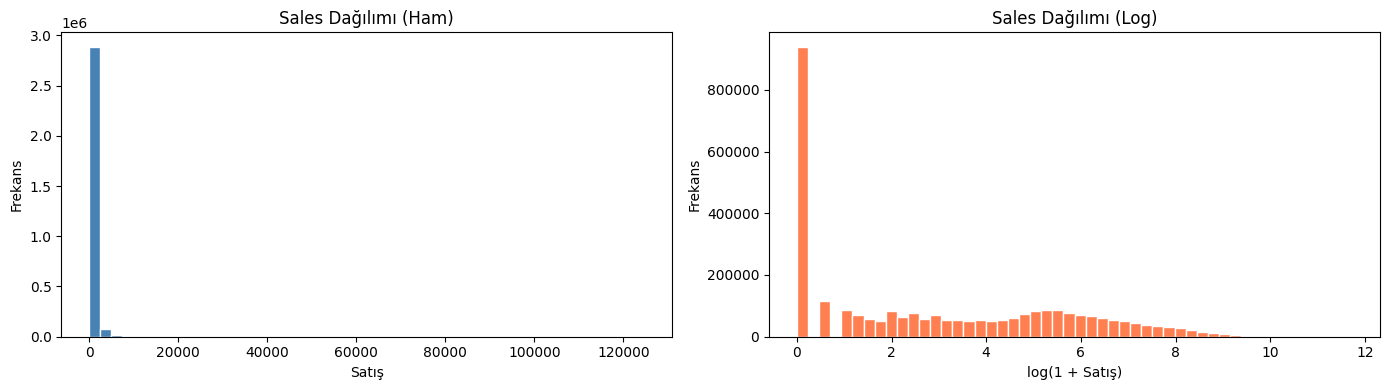

In [54]:
#Hedef Değişken Analizi -sales- (Bu değişkeni derinlemesine tanımalıyız)
#Tahmin etmeye çalıştığımız şey: sales (birim satış)
print(train['sales'].describe()) # sales sütunu istatistikleri
print(f"Sıfır Satış Olan Gün sayısı Oranı: %{(train['sales'] == 0).mean() * 100:.1f}") #Sıfır satış olan gün çok yaygın !!

#Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

#Sol Grafik --> Ham Dağılım 
axes[0].hist(train['sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sales Dağılımı (Ham)')
axes[0].set_xlabel('Satış')
axes[0].set_ylabel('Frekans')

# Sales çok dağınık bu yüzden log ile dağılımın yoğun olduğu yere odaklanılır
#Sağ Grafik --> Log Dağılım 
axes[1].hist(np.log1p(train['sales']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Sales Dağılımı (Log)')
axes[1].set_xlabel('log(1 + Satış)')
axes[1].set_ylabel('Frekans')

plt.tight_layout()
plt.show()

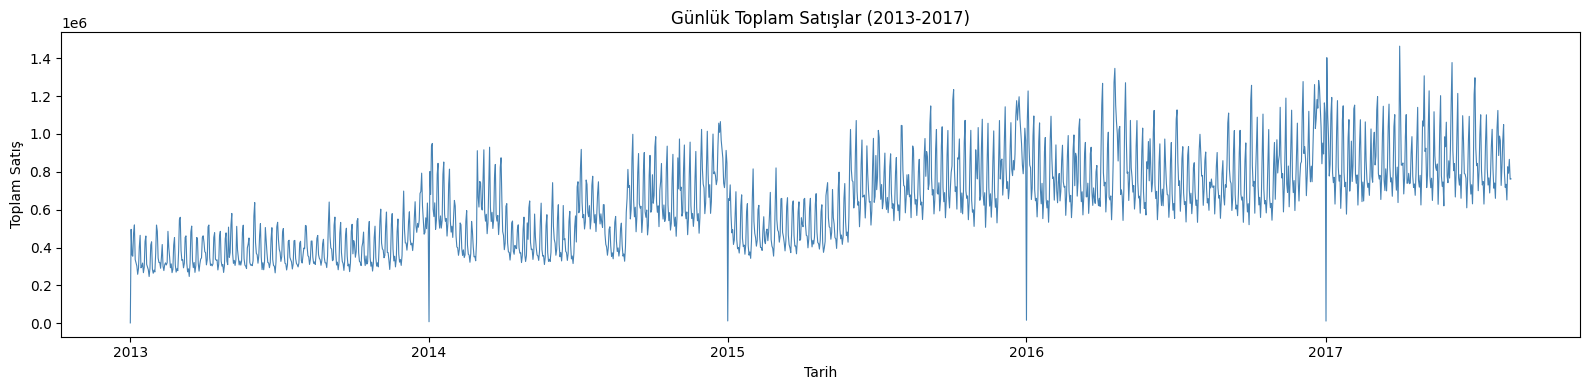

-> Genel Yukarı Trend: Zincir büyüyor olabilitesi fazla
-> Belirli dönemlerde ani düşüşler: Tatil, deprem vb
-> Yılsonu (aralık ayı) artış: Noel etkisi


In [ ]:
# Zaman Analizi - trend ve mevsimsellik etkisi-
# zaman serisi tahmini sayesinde --> Geçmişte ne olmuş? gelecek de buna benzer davranır

#Günlük toplam satışı hesapla
gunluk_satis = train.groupby('date')['sales'].sum().reset_index() #goupby('date')->her tarihi grupla, ['Sales'].sum()-> o günün toplam satışını al

#Görselleştir
plt.figure(figsize=(16, 4))
plt.plot(gunluk_satis['date'], gunluk_satis['sales'],
         color='steelblue', linewidth=0.8)
plt.title('Günlük Toplam Satışlar (2013-2017)')
plt.xlabel('Tarih')
plt.ylabel('Toplam Satış')
plt.tight_layout()
plt.show()

print("-> Genel Yukarı Trend: Zincir büyüyor olabilitesi fazla")
print("-> Belirli dönemlerde ani düşüşler: Tatil, deprem vb")
print("-> Yılsonu (aralık ayı) artış: Noel etkisi")
